In [404]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler
from pathlib import Path
import seaborn as sns
from natsort import natsorted
from math import floor, log10
from sklearn.model_selection import train_test_split

In [460]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

def merge_datasets(datasets):
    """
    Merges a list of datasets (NumPy arrays or Pandas DataFrames) into a single dataset.

    Args:
        datasets: A list of datasets, where each dataset is a NumPy array or a Pandas DataFrame.
                  It is assumed that all datasets have the same number of columns (features).
                  If the datasets have different numbers of columns, the function will still
                  execute, but the results may not be meaningful for subsequent processing.
                  The function does not check for this.

    Returns:
        A single Pandas DataFrame containing all the data from the input datasets.
        Returns an empty DataFrame if the input list is empty.
    """
    if not datasets:
        return pd.DataFrame()  # Return an empty DataFrame if the list is empty

    # Use pd.concat for efficient merging of DataFrames
    merged_data = pd.concat(datasets, axis=0, ignore_index=True)
    return merged_data

def preprocess_data(data, scaler=None):
    """
    Preprocesses the input data by scaling it using StandardScaler.

    Args:
        data: A Pandas DataFrame representing the data to be preprocessed.
        scaler: (Optional) A pre-initialized StandardScaler object. If None,
            a new StandardScaler is initialized and used. If provided,
            the provided scaler is used to transform the data. This is
            useful for applying the same scaling to multiple datasets.

    Returns:
        A tuple containing:
        - The scaled data as a Pandas DataFrame.
        - The StandardScaler object used for scaling. If a scaler was
          passed in, the same scaler is returned.
    """
    # Ensure we are working with a DataFrame
    data = pd.DataFrame(data)

    if scaler is None:
        scaler = StandardScaler()
        # Fit and transform, then convert back to DataFrame
        scaled_data = scaler.fit_transform(data)
        scaled_data = pd.DataFrame(scaled_data, columns=data.columns) # Keep column names
    else:
        # Transform using the provided scaler
        scaled_data = scaler.transform(data)
        scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
    return scaled_data, scaler

def unmerge_datasets(merged_data, original_shapes):
    """
    Unmerges a single dataset into a list of datasets, given the original shapes.

    Args:
        merged_data: A Pandas DataFrame representing the merged dataset.
        original_shapes: A list of tuples, where each tuple represents the shape
            (number of rows, number of columns) of the original dataset.
            The number of columns is not strictly required, but is good practice
            to include. Only the number of rows is used to split the data.
            If the shapes do not add up to the total number of rows in
            `merged_data`, the function will raise a ValueError.

    Returns:
        A list of Pandas DataFrames, where each DataFrame represents an unmerged dataset.
        Returns an empty list if `merged_data` or `original_shapes` is empty.

    Raises:
        ValueError: If the total number of rows in the original shapes do not
            match the number of rows in the merged data.
    """
    if merged_data.empty or not original_shapes:
        return []

    total_rows = sum(rows for rows, _ in original_shapes)
    if total_rows != merged_data.shape[0]:
        raise ValueError(
            f"Total rows in original shapes ({total_rows}) do not match the number of rows in the merged data ({merged_data.shape[0]})"
        )

    unmerged_datasets = []
    start_index = 0
    for rows, _ in original_shapes:
        end_index = start_index + rows
        unmerged_data = merged_data.iloc[start_index:end_index].copy() # Use .iloc for DataFrame slicing and .copy()
        unmerged_datasets.append(unmerged_data)
        start_index = end_index
    return unmerged_datasets

def create_dummy_datasets(num_datasets, num_rows_per_dataset, num_features):
    """
    Creates a list of dummy datasets for testing purposes.  Now creates Pandas DataFrames.

    Args:
        num_datasets: The number of datasets to create.
        num_rows_per_dataset: The number of rows in each dataset.
        num_features: The number of features (columns) in each dataset.

    Returns:
        A list of Pandas DataFrames, where each DataFrame represents a dummy dataset
        with random data.
    """
    datasets = []
    for i in range(num_datasets):
        # Generate random data between 0 and 10
        data = np.random.rand(num_rows_per_dataset, num_features) * 10
        # Create a Pandas DataFrame
        df = pd.DataFrame(data, columns=[f'Feature_{j}' for j in range(num_features)]) # Meaningful column names
        datasets.append(df)
        # Save to CSV for demonstration
        df.to_csv(f"dummy_dataset_{i}.csv", index=False)  # save index=False to avoid extra column
    return datasets

def read_datasets_from_directory(directory, record_shapes=False):
    """
    Reads all CSV files from a specified directory into a list of Pandas DataFrames.

    Args:
        directory: The path to the directory containing the CSV files.
        record_shapes: Boolean indicating whether to record the shapes of the
                       read datasets.  If True, the function also returns a list
                       of the shapes.

    Returns:
        A tuple containing:
        - A list of Pandas DataFrames, where each DataFrame represents a dataset
          read from a CSV file.
        - A list of tuples, where each tuple represents the shape
          (number of rows, number of columns) of the corresponding dataset.
          This is only returned if record_shapes is True.
          Returns an empty list if the directory is empty or does not exist,
          or if no CSV files are found.  Raises an error if a non-CSV file
          is encountered.
    """
    datasets = []
    original_shapes = []
    try:
        # Use os.listdir to get all files in the directory
        for filename in os.listdir(directory):
            if filename.endswith(".csv"):
                filepath = os.path.join(directory, filename)
                try:
                    # Read the CSV file into a Pandas DataFrame
                    df = pd.read_csv(filepath).iloc[:, 1:]
                    if record_shapes:
                        original_shapes.append(df.shape)  # Record shape before appending
                    datasets.append(df)
                except Exception as e:
                    print(f"Error reading file {filename}: {e}") # Inform about file reading errors
            elif os.path.isfile(os.path.join(directory, filename)):
                print(f"Skipping non-CSV file: {filename}") # Inform about skipping non-CSV
        if not datasets:
            print(f"No CSV files found in directory: {directory}")
    except FileNotFoundError:
        print(f"Directory not found: {directory}")
        return [], []  # Return empty lists if directory not found
    except Exception as e:
        print(f"An error occurred: {e}")
        return [], [] # Return empty list if other error.

    if record_shapes:
        return datasets, original_shapes
    else:
        return datasets, []

loaded_datasets, original_shapes = read_datasets_from_directory(Path(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data'), record_shapes=True)
if not loaded_datasets:
    print("No datasets loaded. Exiting.")


print("Original dataset shapes:")
for shape in original_shapes:
    print(shape)

# Merge the datasets
merged_data = merge_datasets(loaded_datasets)
print("\nShape of merged data:", merged_data.shape)

# Preprocess the merged data
scaled_data, scaler = preprocess_data(merged_data)
print("\nShape of scaled data:", scaled_data.shape)

# Unmerge the data
unmerged_datasets = unmerge_datasets(scaled_data, original_shapes)
print("\nUnmerged dataset shapes:")
for shape in [dataset.shape for dataset in unmerged_datasets]:
    print(shape)
    
unmerged_datasets

Original dataset shapes:
(24, 9)
(15, 9)
(32, 9)
(24, 9)
(25, 9)
(23, 9)
(24, 9)
(24, 9)
(24, 9)
(30, 9)
(19, 9)
(14, 9)
(6, 9)
(24, 9)
(30, 9)
(32, 9)
(43, 9)
(13, 9)
(16, 9)
(24, 9)
(13, 9)
(24, 9)
(24, 9)
(32, 9)
(21, 9)
(24, 9)
(10, 9)
(24, 9)
(19, 9)
(9, 9)
(6, 9)
(45, 9)
(22, 9)
(24, 9)
(30, 9)
(43, 9)
(20, 9)
(12, 9)
(12, 9)
(34, 9)
(30, 9)
(24, 9)
(30, 9)
(30, 9)

Shape of merged data: (1028, 9)

Shape of scaled data: (1028, 9)

Unmerged dataset shapes:
(24, 9)
(15, 9)
(32, 9)
(24, 9)
(25, 9)
(23, 9)
(24, 9)
(24, 9)
(24, 9)
(30, 9)
(19, 9)
(14, 9)
(6, 9)
(24, 9)
(30, 9)
(32, 9)
(43, 9)
(13, 9)
(16, 9)
(24, 9)
(13, 9)
(24, 9)
(24, 9)
(32, 9)
(21, 9)
(24, 9)
(10, 9)
(24, 9)
(19, 9)
(9, 9)
(6, 9)
(45, 9)
(22, 9)
(24, 9)
(30, 9)
(43, 9)
(20, 9)
(12, 9)
(12, 9)
(34, 9)
(30, 9)
(24, 9)
(30, 9)
(30, 9)


[        area     speed  perimeter   xcentre   ycentre  eccentricity  \
 0   1.420962  0.662268   2.197796  0.801839 -0.073847      1.397541   
 1   1.297759 -0.200849   1.879073  0.785500 -0.074925      1.417774   
 2   0.747253 -0.546863   1.321308  0.775631 -0.076978      1.220697   
 3   0.410887  0.185975   0.743622  0.755685 -0.065809      1.042827   
 4   0.615249  0.008850   1.022505  0.746331 -0.049442      0.678248   
 5   0.660228 -0.610174   0.922904  0.749337 -0.057185      0.797751   
 6   1.213667 -0.250995   1.201787  0.736435 -0.065008      0.427501   
 7   0.828411 -0.131129   1.002585  0.728715 -0.050482      0.207555   
 8   1.199000  0.607795   1.321308  0.706731 -0.030454      0.642610   
 9   0.628938 -0.284916   1.102186  0.712453 -0.017897      1.347042   
 10  0.702274 -0.948884   1.640031  0.714629 -0.019578      1.288852   
 11  0.767787 -0.980914   1.958753  0.714960 -0.021632      1.396592   
 12  3.841037  3.227958   3.950772  0.653972  0.023504      1.14

In [461]:

#from datetime import datetime
trainX = []
trainY = []

t1 = 'xcentre'
t2 = 'ycentre'

T_list = [t2]
target_num = 1

n_future = 1  # Number of days we want to look into the future based on the past days.
n_past = 2

N = n_future + n_past

#Read the csv file
for i, cell in enumerate(unmerged_datasets):
    if i < 100 :
        df = cell
        redex = [t2]
        #print(cell)  #7 columns, including the Date.
         
        if df.shape[0] > N:
#Separate dates for future plotting
#train_times = pd.to_datetime(df['time']).dt.time
#print(train_times.tail(15))  #Check last few dates.
            for j in list(df):
                if j != t2:
                    redex.append(j)
                else:
                    continue
            
            df = df.reindex(
                columns=redex)
            #Variables for training
            cols = list(df)

        
            #Date and volume columns are not used in training.
            # print(cols)  #['Open', 'High', 'Low', 'Close', 'Adj Close']
            #New dataframe with only training data - 5 columns
            
            df_for_training_scaled = df[cols].astype(float).round(decimals=2)
            

            # df_for_plot=df_for_training.tail(5000)
            # df_for_plot.plot.line()
            
            #LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
            # normalize the dataset
            # scaler = StandardScaler()
            # scaler = scaler.fit(df_for_training)
            # df_for_training_scaled = scaler.transform(df_for_training)
            #print(df_for_training_scaled)
            
            #As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features.
            #In this example, the n_features is 5. We will make timesteps = 14 (past days data used for training).
            
            #Empty lists to be populated using formatted training data
            
            
  # Number of past days we want to use to predict the future.
            
            #Reformat input data into a shape: (n_samples x timesteps x n_features)
            #In my example, my df_for_training_scaled has a shape (12823, 5)
            #12823 refers to the number of data points and 5 refers to the columns (multi-variables).
            for i in range(n_past, len(df_for_training_scaled) - n_future):
                trainX.append(df_for_training_scaled.iloc[i - n_past:i, 0:df_for_training_scaled.shape[1]])
                trainY.append(df_for_training_scaled.iloc[i + n_future - 1:i + n_future, 0]) #encodes number of targets in Y dataset
                        
        else:
            continue
   
   
#print(df_for_training_scaled)        
# trainX, trainY = np.array(trainX), np.array(trainY)
X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size =1, random_state=16)
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)


print('X_train shape == {}.'.format(X_train.shape))
print('y_train shape == {}.'.format(y_train.shape))

print('X_test shape == {}.'.format(X_test.shape))
print('y_test shape == {}.'.format(y_test.shape))

#In my case, trainX has a shape (12809, 14, 5).
        #12809 because we are looking back 14 days (12823 - 14 = 12809).
        #Remember that we cannot look back 14 days until we get to the 15th day.
        #Also, trainY has a shape (12809, 1). Our model only predicts a single value, but
        #it needs multiple variables (5 in my example) to make this prediction.
        #This is why we can only predict a single day after our training, the day after where our data ends.
        #To predict more days in future, we need all the 5 variables which we do not have.
        #We need to predict all variables if we want to do that.

X_train shape == (895, 2, 9).
y_train shape == (895, 1).
X_test shape == (1, 2, 9).
y_test shape == (1, 1).


In [ ]:

#from datetime import datetime
trainX = []
trainY = []

t1 = 'xcentre'
t2 = 'ycentre'

T_list = [t2]
target_num = 1

n_future = 1  # Number of days we want to look into the future based on the past days.
n_past = 2

N = n_future + n_past

#Read the csv file
for i, cell in enumerate(natsorted((Path(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data').iterdir()))):
    if i < 100 :
        redex = [t2]
        df = pd.read_csv(cell)
        #print(cell)  #7 columns, including the Date.
         
        if df.shape[0] > N:
            print(cell)
#Separate dates for future plotting
#train_times = pd.to_datetime(df['time']).dt.time
#print(train_times.tail(15))  #Check last few dates.
            for j in list(df)[1:]:
                if j != t2:
                    redex.append(j)
                else:
                    continue
            
            df = df.reindex(
                columns=redex)
            #Variables for training
            cols = list(df)
            #Date and volume columns are not used in training.
            # print(cols)  #['Open', 'High', 'Low', 'Close', 'Adj Close']
            #New dataframe with only training data - 5 columns
            
            df_for_training = df[cols].astype(float).round(decimals=2)
         
            # df_for_plot=df_for_training.tail(5000)
            # df_for_plot.plot.line()
            
            #LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
            # normalize the dataset
            scaler = StandardScaler()
            scaler = scaler.fit(df_for_training)
            df_for_training_scaled = scaler.transform(df_for_training)
            #print(df_for_training_scaled)
            
            #As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features.
            #In this example, the n_features is 5. We will make timesteps = 14 (past days data used for training).
            
            #Empty lists to be populated using formatted training data
            
            
  # Number of past days we want to use to predict the future.
            
            #Reformat input data into a shape: (n_samples x timesteps x n_features)
            #In my example, my df_for_training_scaled has a shape (12823, 5)
            #12823 refers to the number of data points and 5 refers to the columns (multi-variables).
            for i in range(n_past, len(df_for_training_scaled) - n_future):
                trainX.append(df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])
                trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0]) #encodes number of targets in Y dataset
                        
        else:
            continue
   
   
#print(df_for_training_scaled)        
# trainX, trainY = np.array(trainX), np.array(trainY)
X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size =1, random_state=16)
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)


print('X_train shape == {}.'.format(X_train.shape))
print('y_train shape == {}.'.format(y_train.shape))

print('X_test shape == {}.'.format(X_test.shape))
print('y_test shape == {}.'.format(y_test.shape))

#In my case, trainX has a shape (12809, 14, 5).
        #12809 because we are looking back 14 days (12823 - 14 = 12809).
        #Remember that we cannot look back 14 days until we get to the 15th day.
        #Also, trainY has a shape (12809, 1). Our model only predicts a single value, but
        #it needs multiple variables (5 in my example) to make this prediction.
        #This is why we can only predict a single day after our training, the day after where our data ends.
        #To predict more days in future, we need all the 5 variables which we do not have.
        #We need to predict all variables if we want to do that.

In [462]:
X_train.shape[1]

2

In [463]:
X_train.shape[2]

9

In [469]:
# define the Autoencoder model

model = Sequential()
model.add(LSTM(150, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, activation='relu'))
model.add(Dense(64))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

# fit the model

C:\Users\2MY\anaconda3\envs\Research\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_102 (LSTM)                 │ (None, 2, 150)         │        96,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_103 (LSTM)                 │ (None, 64)             │        55,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,265 (606.50 KB)

 Trainable params: 155,265 (606.50 KB)

 Non-trainable params: 0 (0.00 B)

In [471]:
prediction_copies = np.hstack((np.vstack((model.predict(X_test), y_test)), np.zeros((2,df_for_training_scaled.shape[1] - y_test.shape[1]))))
Test = scaler.inverse_transform(prediction_copies)[:, 0]
print(((Test[1]-Test[0])/Test[1])*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1.5825572396017566


In [470]:
acc_df = []
for i in range(2,3):
    history = model.fit(X_train, y_train, epochs=i, batch_size=16, validation_split=0.2, verbose=1)
    scaled_res = np.vstack((model.predict(X_test), y_test))
    prediction_copies = np.hstack((scaled_res, np.zeros((len(scaled_res),df_for_training_scaled.shape[1] - y_test.shape[1]))))
    
    acc_df.append(scaler.inverse_transform(prediction_copies)[:, 0])
    
    


Epoch 1/2
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8030 - val_loss: 0.0663
Epoch 2/2
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0416 - val_loss: 0.0090
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [403]:
acc_df

[array([253.90642352, 254.74368937])]

In [383]:
prediction_copies = np.hstack((model.predict(X_test), y_test, np.zeros((y_test.shape[1],df_for_training_scaled.shape[1] - y_test.shape[1]*2 ))))
scaler.inverse_transform(prediction_copies)[:, 0:2]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[ 253.26888227, 2564.00317467]])

In [345]:
results = np.array(acc_df).reshape(len(acc_df), np.shape(acc_df)[2])
results = pd.DataFrame(np.c_[np.arange(1,len(acc_df) + 1),results], columns=['epoch', 'X_pred', 'y_pred', 'X_truth', 'y_truth'])
results

,epoch,X_pred,y_pred,X_truth,y_truth
0,1.0,903.120428,253.726113,2807.56768,5.196575
1,2.0,903.323899,253.759830,2807.56768,5.196575
2,3.0,903.366311,253.692566,2807.56768,5.196575
3,4.0,903.049700,253.670190,2807.56768,5.196575
4,5.0,903.177111,253.651269,2807.56768,5.196575
5,6.0,902.849576,253.557347,2807.56768,5.196575
6,7.0,902.760407,253.641307,2807.56768,5.196575
7,8.0,902.583238,253.671752,2807.56768,5.196575
8,9.0,903.200195,253.643168,2807.56768,5.196575
9,10.0,903.045071,253.652805,2807.56768,5.196575


In [306]:
acc_df = pd.DataFrame(acc_df.reshape(3,-1))
acc_df

ValueError: Must pass 2-d input. shape=(2, 1, 4)

In [264]:
prediction_copies = np.concatenate((acc_df, np.zeros((len(acc_df),df_for_training_scaled.shape[1] - 2,2))), axis=-1)
prediction_copies

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 3 dimension(s)

In [239]:
scaler.inverse_transform(prediction_copies)

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 2 dimension(s)

In [237]:
y_test

array([[[-0.84430851,  0.83844548]]])

In [170]:
df_for_training

,xcentre,area,speed,perimeter,eccentricity,orientation,major_axis,minor_axis
0,861.48,2005.00,4.78,201.00,0.56,-0.09,55.52,46.18
1,861.60,2382.00,1.85,220.00,0.47,0.16,58.93,51.98
2,861.41,2648.00,0.99,238.00,0.62,0.04,66.05,51.56
3,865.55,2510.00,4.42,230.00,0.62,0.01,64.04,50.02
4,869.72,2680.00,6.22,236.00,0.57,0.26,64.56,53.24
5,870.83,2638.00,2.99,236.00,0.74,0.50,70.76,47.93
6,874.23,2586.00,5.01,229.00,0.67,0.22,66.66,49.72
7,879.30,2786.00,6.09,234.00,0.75,0.18,73.45,48.56
8,882.65,2527.00,5.26,228.00,0.57,0.31,62.97,51.85
9,890.05,2928.00,9.97,256.00,0.51,0.58,66.37,57.04


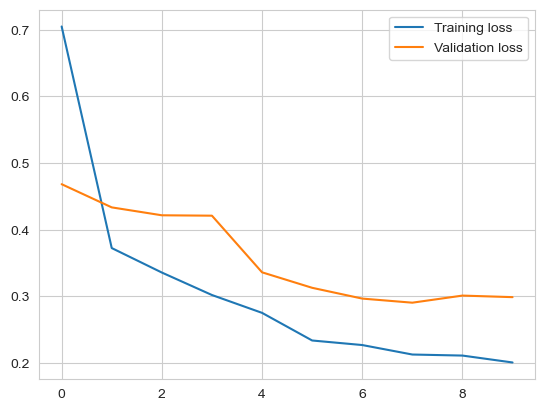

In [397]:

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()